In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score



In [6]:
df = pd.read_csv('weather_data_extended.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Location          800 non-null    object 
 1   Temperature (°C)  800 non-null    float64
 2   Feels Like (°C)   800 non-null    float64
 3   Humidity (%)      798 non-null    float64
 4   Wind Speed (kph)  798 non-null    float64
 5   Cloud Cover (%)   800 non-null    int64  
 6   Pressure (mb)     798 non-null    float64
 7   UV Index          800 non-null    int64  
 8   Visibility (km)   800 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 56.4+ KB


,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
0,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
1,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
2,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
3,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16
4,New York,8.3,4.5,40.0,29.9,75,1003.0,2,16


In [7]:
df.isnull().sum()

Location            0
Temperature (°C)    0
Feels Like (°C)     0
Humidity (%)        2
Wind Speed (kph)    2
Cloud Cover (%)     0
Pressure (mb)       2
UV Index            0
Visibility (km)     0
dtype: int64

In [8]:
df_no_mv = df.dropna()

In [9]:
df_no_mv.describe()

,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,16.580730,16.373804,73.513854,16.123300,43.513854,1013.041562,1.746851,10.732997
std,5.574821,7.382814,16.478897,10.338986,34.845115,7.608453,1.092285,1.966105
min,8.300000,4.500000,40.000000,3.600000,0.000000,900.000000,1.000000,10.000000
25%,15.000000,13.800000,67.000000,6.100000,0.000000,1012.000000,1.000000,10.000000
50%,16.000000,16.000000,76.000000,9.000000,50.000000,1013.000000,1.000000,10.000000
75%,24.000000,25.500000,88.000000,24.100000,75.000000,1019.250000,2.000000,10.000000
max,25.000000,27.800000,100.000000,29.900000,75.000000,1024.000000,4.000000,16.000000


In [68]:
df_no_mv.head()

,Location,Temperature (°C),Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km)
0,New York,8.30,4.50,40.00,29.90,75,1003.00,2,16
1,New York,8.30,4.50,40.00,29.90,75,1003.00,2,16
2,New York,8.30,4.50,40.00,29.90,75,1003.00,2,16
3,New York,8.30,4.50,40.00,29.90,75,1003.00,2,16
4,New York,8.30,4.50,40.00,29.90,75,1003.00,2,16


In [69]:


# String indexing on 'Location' column: Converting Location column from string to integer
df_no_mv['Location_index'] = df_no_mv['Location'].astype('category').cat.codes  

# Get unique values from each column
unique_locations = df_no_mv['Location'].drop_duplicates().reset_index(drop=True)
unique_location_indices = df_no_mv['Location_index'].drop_duplicates().reset_index(drop=True) 

# Create a new DataFrame with both columns
unique_df = pd.DataFrame({
    'Unique_Locations': unique_locations,
    'Unique_Location_Indices': unique_location_indices
})
unique_df

/tmp/ipykernel_3704/1323813928.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_mv['Location_index'] = df_no_mv['Location'].astype('category').cat.codes  # Changed df_no_mv to df


,Unique_Locations,Unique_Location_Indices
0,New York,3
1,London,2
2,Tokyo,7
3,Paris,4
4,Sydney,6
5,Dubai,0
6,Rome,5
7,Hong Kong,1


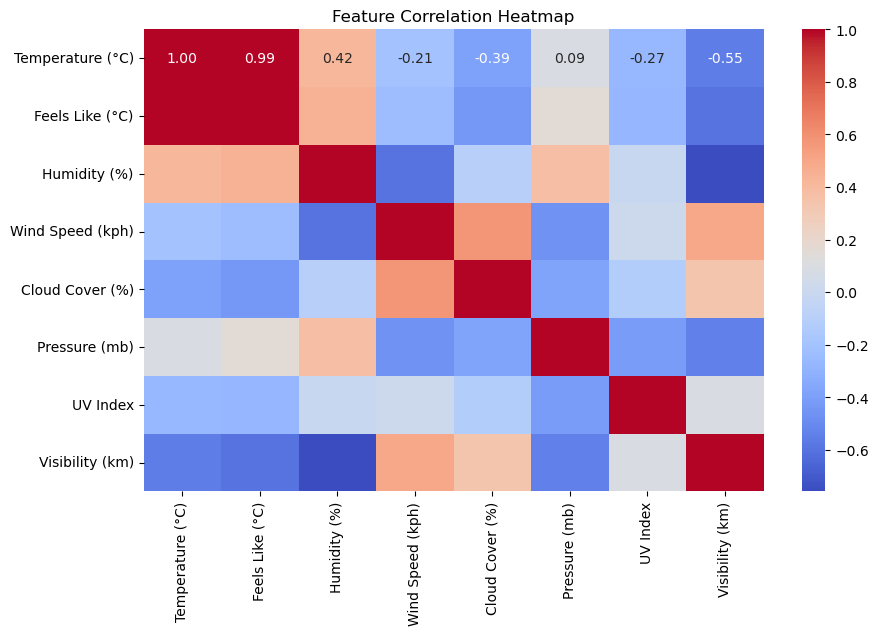

In [46]:
# Select only numeric columns before correlation
numeric_df = df_no_mv.select_dtypes(include=['number'])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

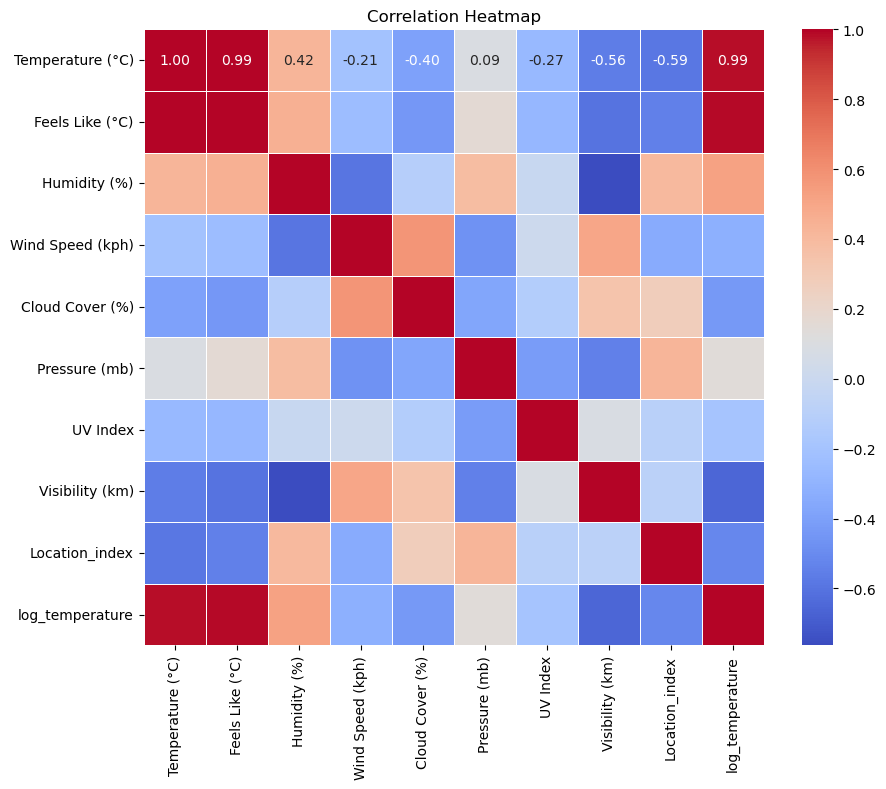

In [47]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

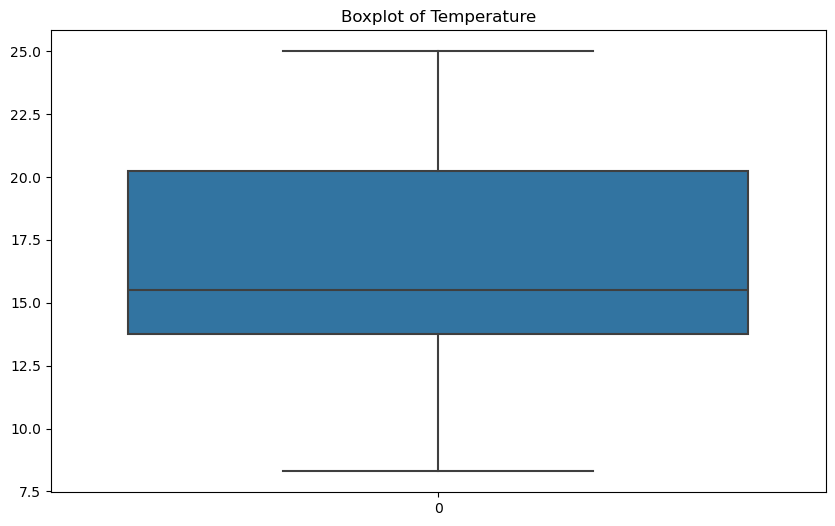

In [48]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Temperature (°C)'])
plt.title('Boxplot of Temperature')
plt.show()

/tmp/ipykernel_3704/584637436.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Temperature (°C)'])
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Temperature (°C)', ylabel='Density'>

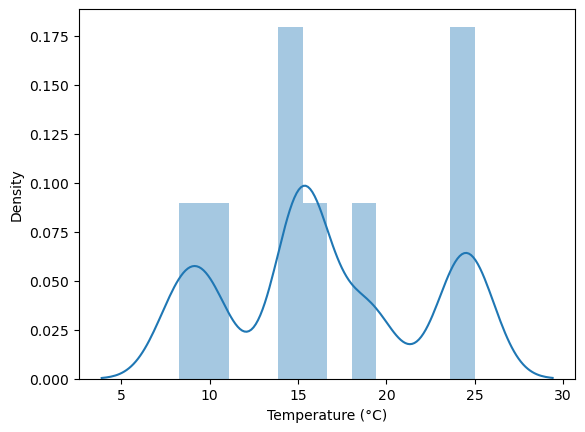

In [49]:
sns.distplot(df['Temperature (°C)'])

/tmp/ipykernel_3704/1584252955.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Pressure (mb)'])
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Pressure (mb)', ylabel='Density'>

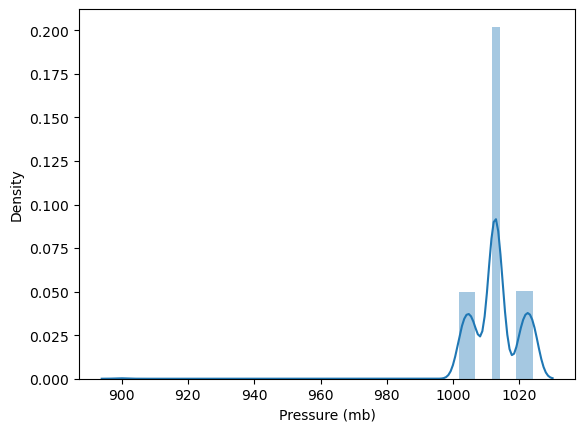

In [50]:
sns.distplot(df['Pressure (mb)'])

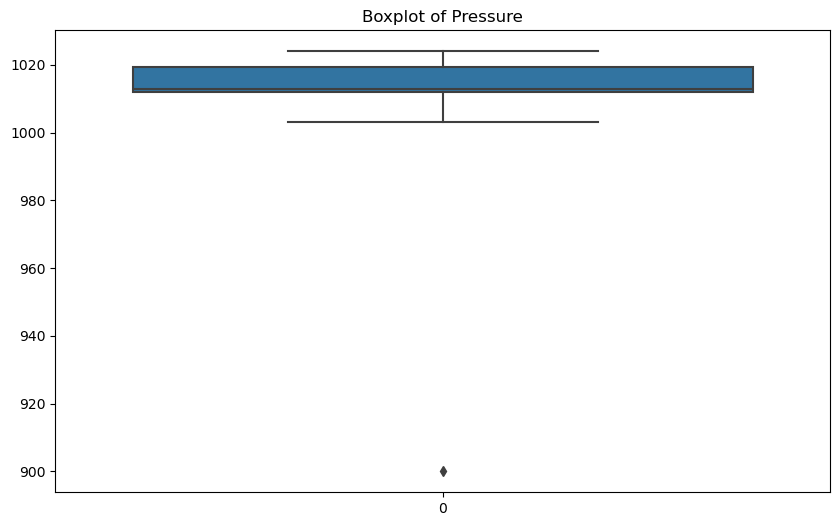

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Pressure (mb)'])
plt.title('Boxplot of Pressure')
plt.show()

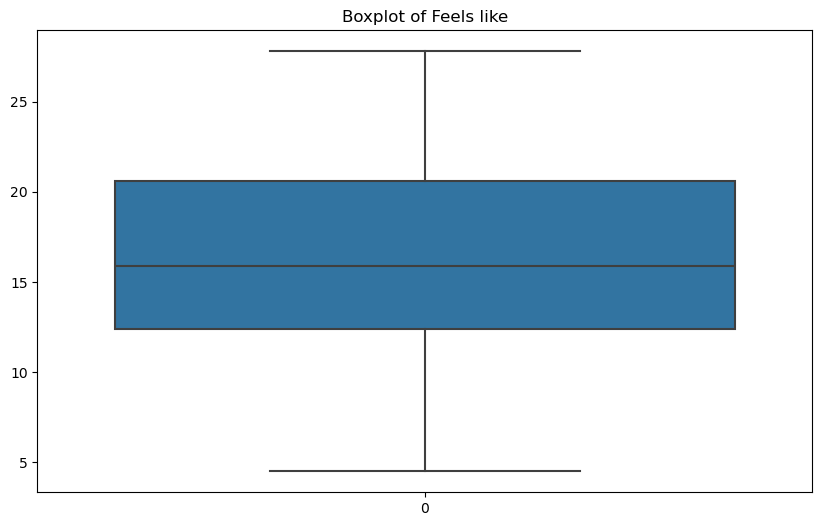

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Feels Like (°C)'])
plt.title('Boxplot of Feels like')
plt.show()

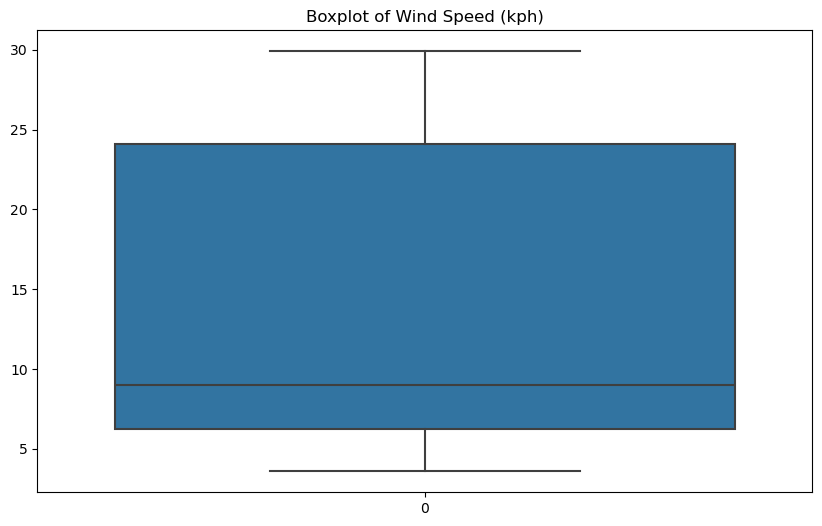

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Wind Speed (kph)'])
plt.title('Boxplot of Wind Speed (kph)')
plt.show()

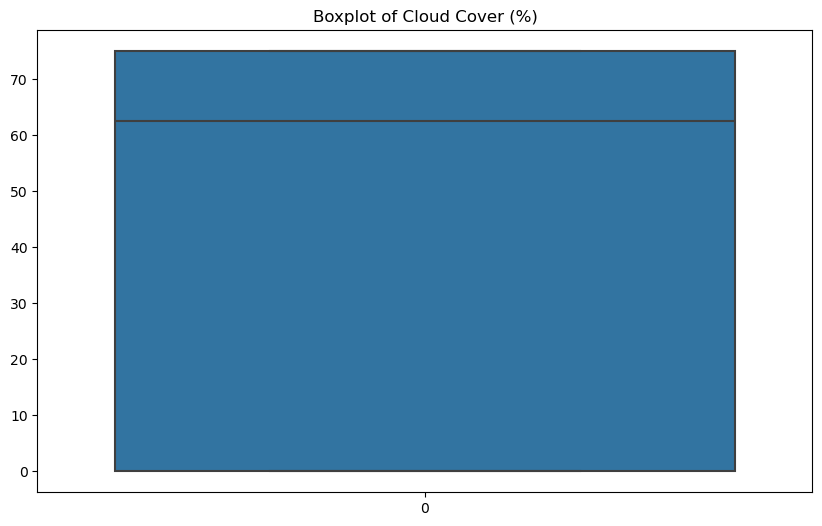

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Cloud Cover (%)'])
plt.title('Boxplot of Cloud Cover (%)')
plt.show()

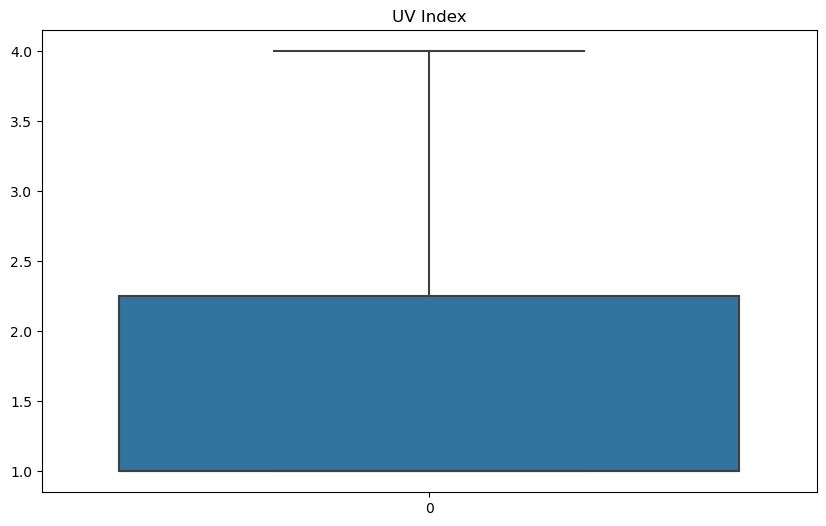

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['UV Index'])
plt.title('UV Index')
plt.show()

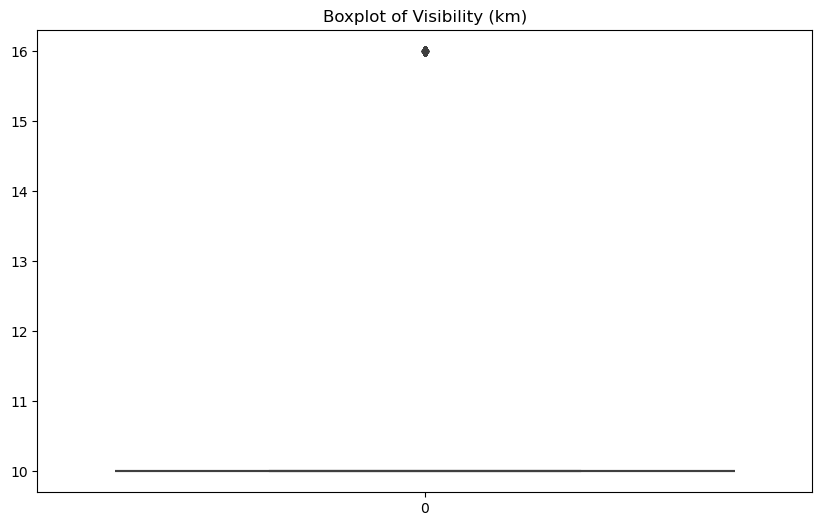

In [56]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Visibility (km)'])
plt.title('Boxplot of Visibility (km)')
plt.show()

/tmp/ipykernel_3704/3148728218.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Visibility (km)'])
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Visibility (km)', ylabel='Density'>

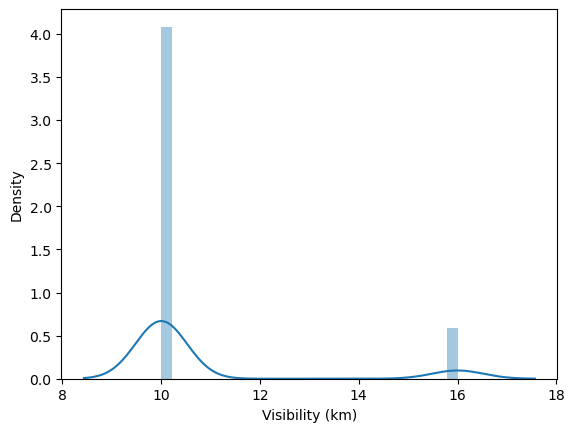

In [57]:
sns.distplot(df['Visibility (km)'])

/tmp/ipykernel_3704/2382286491.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['UV Index'])
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='UV Index', ylabel='Density'>

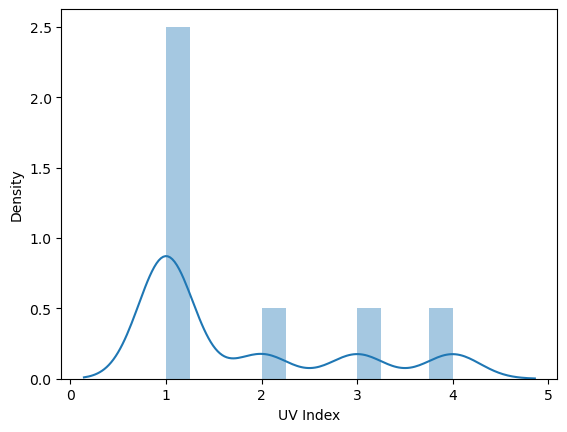

In [58]:
sns.distplot(df['UV Index'])

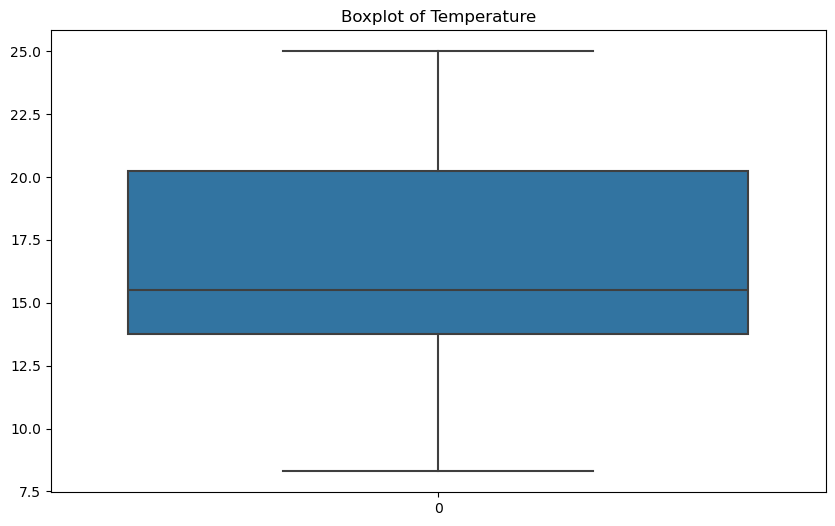

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Temperature (°C)'])
plt.title('Boxplot of Temperature')
plt.show()

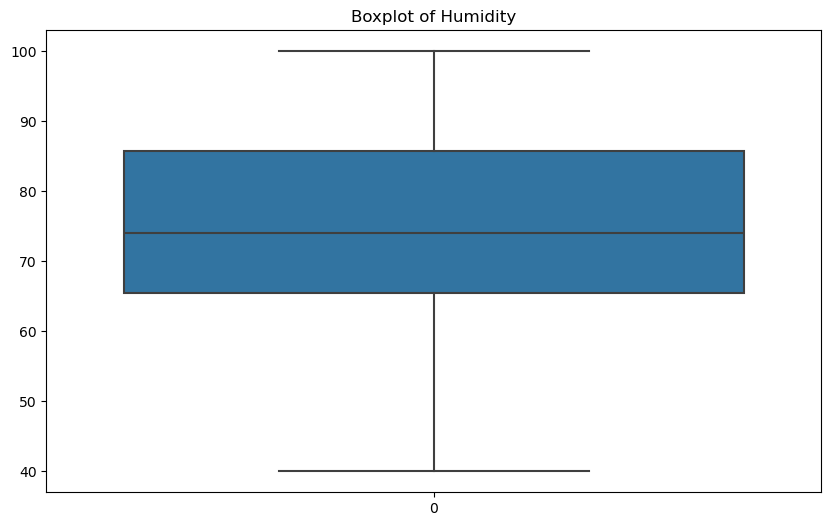

In [60]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df['Humidity (%)'])
plt.title('Boxplot of Humidity')
plt.show()

In [77]:
log_temperature = np.log(df['Temperature (°C)'])

df['log_temperature'] = log_temperature




In [71]:
df_logTemp = df.drop(['Temperature (°C)'],axis=1)
df_logTemp.head()

,Location,Feels Like (°C),Humidity (%),Wind Speed (kph),Cloud Cover (%),Pressure (mb),UV Index,Visibility (km),Location_index,log_temperature
0,New York,4.50,40.00,29.90,75,1003.00,2,16,3,2.12
1,New York,4.50,40.00,29.90,75,1003.00,2,16,3,2.12
2,New York,4.50,40.00,29.90,75,1003.00,2,16,3,2.12
3,New York,4.50,40.00,29.90,75,1003.00,2,16,3,2.12
4,New York,4.50,40.00,29.90,75,1003.00,2,16,3,2.12


In [95]:
df_logTemp = df.dropna()

In [96]:
X = df_logTemp[['Humidity (%)', 'Wind Speed (kph)', 'Pressure (mb)', 'Visibility (km)', 'Location_index']] #features
y = df_logTemp['log_temperature'] #target variable or label 	



In [97]:
# scaling the values in features to handle outliers
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print(df_scaled.describe())

       Humidity (%)  Wind Speed (kph)  Pressure (mb)  Visibility (km)  \
count        794.00            794.00         794.00           794.00   
mean          -0.12              0.40           0.01             0.73   
std            0.78              0.57           1.05             1.97   
min           -1.71             -0.30         -15.59             0.00   
25%           -0.43             -0.16          -0.14             0.00   
50%            0.00              0.00           0.00             0.00   
75%            0.57              0.84           0.86             0.00   
max            1.14              1.16           1.52             6.00   

       Location_index  
count          794.00  
mean            -0.10  
std              0.48  
min             -0.84  
25%             -0.63  
50%              0.00  
75%              0.37  
max              0.63  


In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [100]:
y_pred = model.predict(X_test)

In [101]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')
print(f'mean_absolute_error: {mae:.2f}')

Mean Squared Error: 0.01
R-squared Score: 0.96
mean_absolute_error: 0.06


In [102]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("Cross-Validation R-squared Scores:", scores)
print("Average R-squared:", scores.mean())


Cross-Validation R-squared Scores: [-0.58279644  0.72894495 -1.7619396   0.59259387 -0.84219223]
Average R-squared: -0.37307788947119497


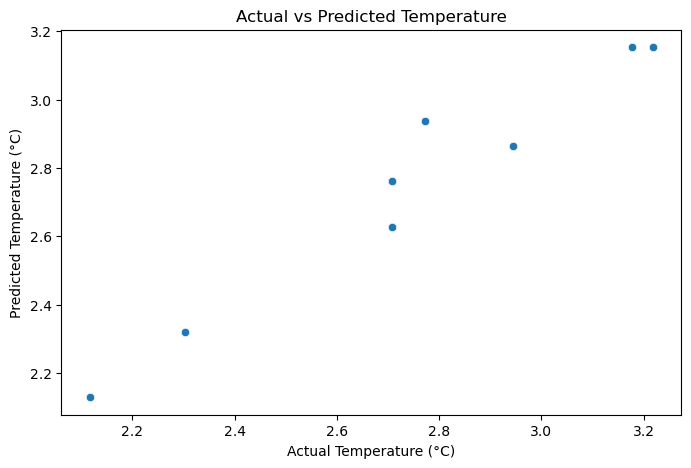

In [103]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperature')
plt.show()

In [104]:
# Finally, let's manually check these predictions
# To obtain the actual prices, we take the exponential of the log_price
df_pf = pd.DataFrame(np.exp(y_pred), columns=['Prediction'])
df_pf.head()

,Prediction
0,13.85
1,23.42
2,8.41
3,23.40
4,8.41


In [105]:
df_pf['Target'] = np.exp(y_test)
df_pf

,Prediction,Target
0,13.85,NaN
1,23.42,NaN
2,8.41,8.30
3,23.40,NaN
4,8.41,NaN
5,23.42,NaN
6,18.87,NaN
7,13.85,NaN
8,23.40,8.30
9,13.85,NaN


In [106]:
# We have missing values Therefore, to get a proper result, we must reset the index and drop the old indexing
y_test = y_test.reset_index(drop=True)

# Check the result
y_test.head()

0   2.71
1   3.22
2   2.12
3   3.18
4   2.12
Name: log_temperature, dtype: float64

In [107]:
# Let's overwrite the 'Target' column with the appropriate values
# Again, we need the exponential of the test log price
df_pf['Target'] = np.exp(y_test)
df_pf

,Prediction,Target
0,13.85,15.00
1,23.42,25.00
2,8.41,8.30
3,23.40,24.00
4,8.41,8.30
5,23.42,25.00
6,18.87,16.00
7,13.85,15.00
8,23.40,24.00
9,13.85,15.00


In [108]:
#Additionally, we can calculate the difference between the targets and the predictions
df_pf['Residual'] = df_pf['Target'] - df_pf['Prediction']

In [109]:
# Finally, it makes sense to see how far off we are from the result percentage-wise
# Here, we take the absolute difference in %, so we can easily order the data frame
df_pf['Difference%'] = np.absolute(df_pf['Residual']/df_pf['Target']*100)
df_pf

,Prediction,Target,Residual,Difference%
0,13.85,15.00,1.15,7.70
1,23.42,25.00,1.58,6.33
2,8.41,8.30,-0.11,1.31
3,23.40,24.00,0.60,2.49
4,8.41,8.30,-0.11,1.31
5,23.42,25.00,1.58,6.33
6,18.87,16.00,-2.87,17.94
7,13.85,15.00,1.15,7.70
8,23.40,24.00,0.60,2.49
9,13.85,15.00,1.15,7.70


In [110]:
# Exploring the descriptives here gives us additional insights
df_pf.describe()

,Prediction,Target,Residual,Difference%
count,159.00,159.00,159.00,159.00
mean,16.27,16.50,0.23,6.20
std,5.37,5.76,1.35,4.90
min,8.41,8.30,-2.87,1.31
25%,10.19,10.00,-0.19,1.87
50%,17.54,16.00,0.60,6.33
75%,23.40,24.00,1.46,7.70
max,23.42,25.00,1.58,17.94


In [111]:

# Sometimes it is useful to check these outputs manually
# To see all rows, we use the relevant pandas syntax
pd.options.display.max_rows = 999
# Moreover, to make the dataset clear, we can display the result with only 2 digits after the dot 
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# Finally, we sort by difference in % and manually check the model
df_pf.sort_values(by=['Difference%'])

,Prediction,Target,Residual,Difference%
144,8.41,8.30,-0.11,1.31
25,8.41,8.30,-0.11,1.31
89,8.41,8.30,-0.11,1.31
98,8.41,8.30,-0.11,1.31
83,8.41,8.30,-0.11,1.31
82,8.41,8.30,-0.11,1.31
69,8.41,8.30,-0.11,1.31
73,8.41,8.30,-0.11,1.31
127,8.41,8.30,-0.11,1.31
74,8.41,8.30,-0.11,1.31
